In [1]:
import pandas as pd

print("Chargement en cours... (peut prendre 1-2 minutes)")

df = pd.read_excel("../data/globalterrorismdb_0522dist.xlsx", engine="openpyxl")

print(f"✓ Chargement réussi !")
print(f"Nombre de lignes   : {len(df):,}")
print(f"Nombre de colonnes : {df.shape[1]}")

Chargement en cours... (peut prendre 1-2 minutes)
✓ Chargement réussi !
Nombre de lignes   : 209,706
Nombre de colonnes : 135


In [2]:
# Aperçu des premières lignes
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaT,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaT,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaT,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaT,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaT,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [3]:
# Colonnes disponibles
print(df.columns.tolist())

['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended', 'resolution', 'country', 'country_txt', 'region', 'region_txt', 'provstate', 'city', 'latitude', 'longitude', 'specificity', 'vicinity', 'location', 'summary', 'crit1', 'crit2', 'crit3', 'doubtterr', 'alternative', 'alternative_txt', 'multiple', 'success', 'suicide', 'attacktype1', 'attacktype1_txt', 'attacktype2', 'attacktype2_txt', 'attacktype3', 'attacktype3_txt', 'targtype1', 'targtype1_txt', 'targsubtype1', 'targsubtype1_txt', 'corp1', 'target1', 'natlty1', 'natlty1_txt', 'targtype2', 'targtype2_txt', 'targsubtype2', 'targsubtype2_txt', 'corp2', 'target2', 'natlty2', 'natlty2_txt', 'targtype3', 'targtype3_txt', 'targsubtype3', 'targsubtype3_txt', 'corp3', 'target3', 'natlty3', 'natlty3_txt', 'gname', 'gsubname', 'gname2', 'gsubname2', 'gname3', 'gsubname3', 'motive', 'guncertain1', 'guncertain2', 'guncertain3', 'individual', 'nperps', 'nperpcap', 'claimed', 'claimmode', 'claimmode_txt', 'claim2', 'claimmode2', 'claim

In [4]:
df.tail()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
209701,202012310015,2020,12,31,2020-12-31 00:00:00,0,NaT,228,Yemen,10,...,NaN,"""Al Houthi militia escalated in Hays and targe...",NaN,NaN,START Primary Collection,0,0,0,0,NaN
209702,202012310016,2020,12,31,2020-12-31 00:00:00,0,NaT,228,Yemen,10,...,NaN,"""Al Houthi militia escalated in Hays and targe...",NaN,NaN,START Primary Collection,0,0,0,0,NaN
209703,202012310017,2020,12,31,NaN,0,NaT,75,Germany,8,...,NaN,"""Far-left arson attack suspected on German asy...","""Fire of Bundeswehr vehicles in Leipzig, proba...","""Anarchist Antifa Take Credit for Arson Attack...",START Primary Collection,-9,-9,0,-9,NaN
209704,202012310018,2020,12,31,NaN,0,NaT,4,Afghanistan,6,...,NaN,"""Civil society activist and tribal elder kille...","""Terrorism Digest: 1-2 Jan 21,"" BBC Monitoring...",NaN,START Primary Collection,-9,-9,0,-9,NaN
209705,202012310019,2020,12,31,NaN,1,NaT,33,Burkina Faso,11,...,NaN,"""Terrorism Digest: 3-4 Jan 21,"" BBC Monitoring...",NaN,NaN,START Primary Collection,-9,-9,0,-9,NaN


In [5]:
COLONNES_UTILES = [
    "eventid",
    "iyear", "imonth", "iday",
    "country_txt", "region_txt",
    "latitude", "longitude",
    "attacktype1_txt",
    "targtype1_txt",
    "gname",
    "weaptype1_txt",
    "nkill", "nwound",
    "success", "suicide"
]

df = df[COLONNES_UTILES].copy()

print(f"Colonnes conservées : {df.shape[1]}")
print(f"Lignes : {len(df):,}")
print()
print(df.isnull().sum())

Colonnes conservées : 16
Lignes : 209,706

eventid                0
iyear                  0
imonth                 0
iday                   0
country_txt            0
region_txt             0
latitude            4691
longitude           4692
attacktype1_txt        0
targtype1_txt          0
gname                  0
weaptype1_txt          0
nkill              12527
nwound             19936
success                0
suicide                0
dtype: int64


In [6]:
# Supprimer les lignes sans coordonnées GPS (indispensables pour la carte et les cellules)
df = df.dropna(subset=["latitude", "longitude"])

# Remplacer les NaN de nkill et nwound par 0
df["nkill"]  = df["nkill"].fillna(0).clip(lower=0)
df["nwound"] = df["nwound"].fillna(0).clip(lower=0)

print(f"Lignes après nettoyage : {len(df):,}")
print(f"Valeurs manquantes restantes :")
print(df.isnull().sum())

Lignes après nettoyage : 205,014
Valeurs manquantes restantes :
eventid            0
iyear              0
imonth             0
iday               0
country_txt        0
region_txt         0
latitude           0
longitude          0
attacktype1_txt    0
targtype1_txt      0
gname              0
weaptype1_txt      0
nkill              0
nwound             0
success            0
suicide            0
dtype: int64


In [7]:
print("TOP 10 PAYS")
print(df["country_txt"].value_counts().head(10))
print()

print("TYPES D'ATTAQUES")
print(df["attacktype1_txt"].value_counts())
print()

print("TOP 10 ORGANISATIONS")
print(df["gname"].value_counts().head(10))
print()

print("INCIDENTS PAR ANNÉE")
print(df.groupby("iyear").size())

TOP 10 PAYS
country_txt
Iraq              27355
Afghanistan       18814
Pakistan          15453
India             13770
Colombia           8440
Philippines        7890
Yemen              5916
Peru               5822
United Kingdom     5505
Nigeria            5503
Name: count, dtype: int64

TYPES D'ATTAQUES
attacktype1_txt
Bombing/Explosion                      96699
Armed Assault                          47978
Assassination                          21040
Hostage Taking (Kidnapping)            13517
Facility/Infrastructure Attack         12153
Unknown                                10573
Unarmed Assault                         1199
Hostage Taking (Barricade Incident)     1127
Hijacking                                728
Name: count, dtype: int64

TOP 10 ORGANISATIONS
gname
Unknown                                             90580
Taliban                                             11954
Islamic State of Iraq and the Levant (ISIL)          7220
Al-Shabaab                                 

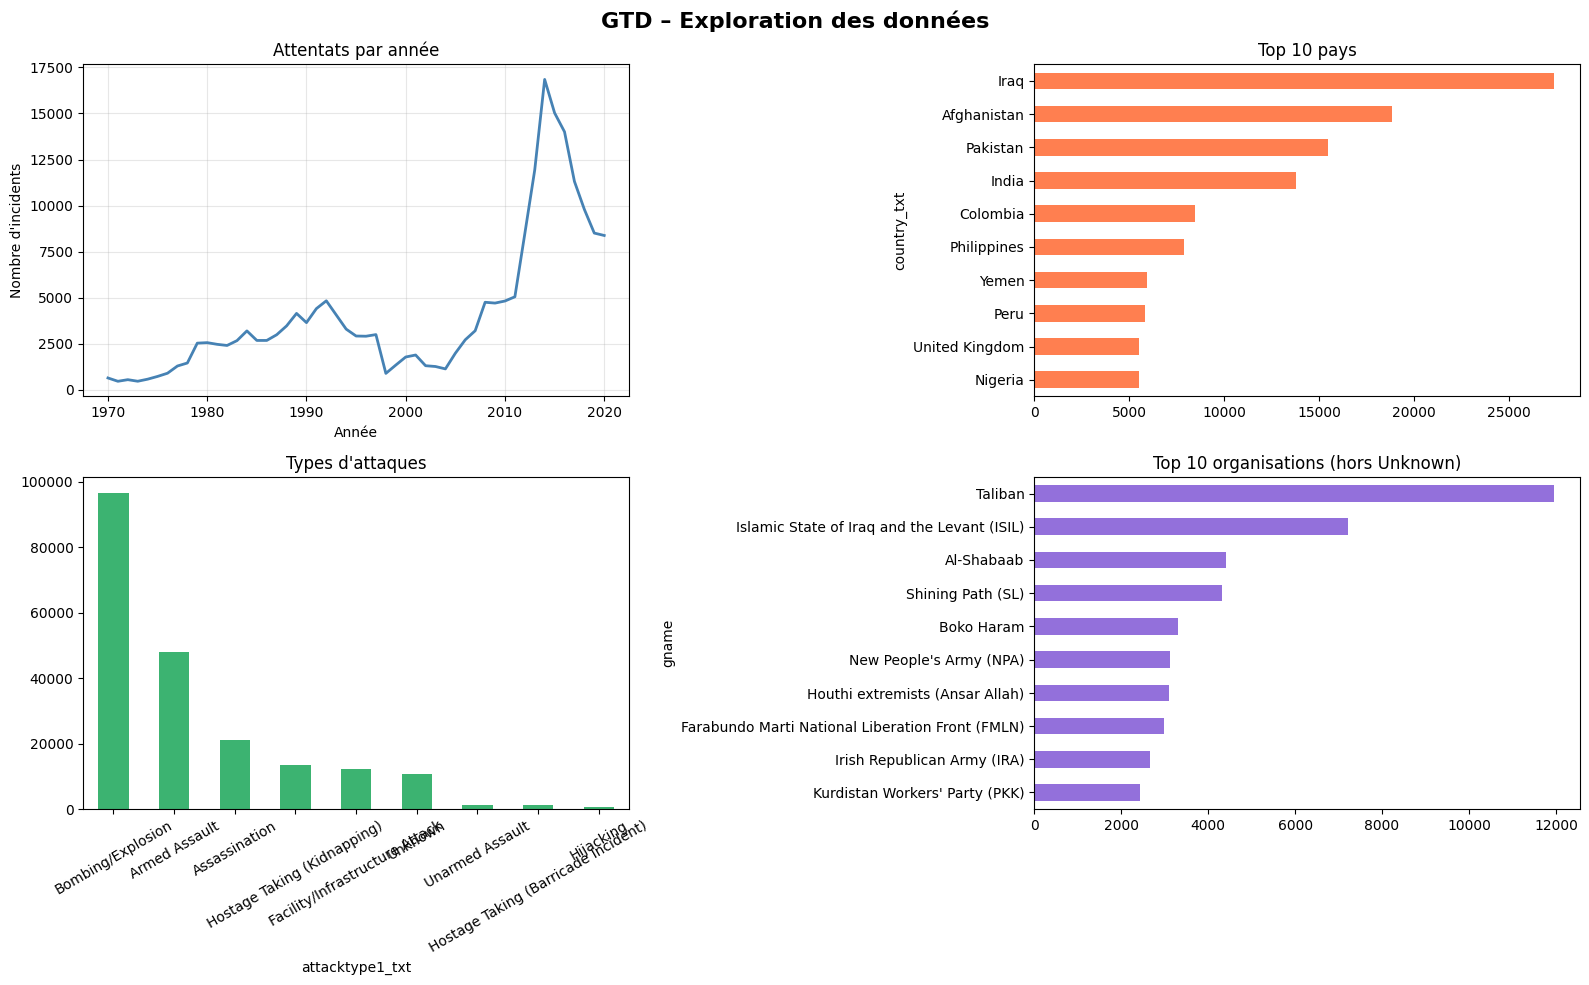

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("GTD – Exploration des données", fontsize=16, fontweight="bold")

# Évolution temporelle
df.groupby("iyear").size().plot(ax=axes[0,0], color="steelblue", linewidth=2)
axes[0,0].set_title("Attentats par année")
axes[0,0].set_xlabel("Année")
axes[0,0].set_ylabel("Nombre d'incidents")
axes[0,0].grid(alpha=0.3)

# Top 10 pays
df["country_txt"].value_counts().head(10).plot(kind="barh", ax=axes[0,1], color="coral")
axes[0,1].set_title("Top 10 pays")
axes[0,1].invert_yaxis()

# Types d'attaques
df["attacktype1_txt"].value_counts().plot(kind="bar", ax=axes[1,0], color="mediumseagreen", rot=30)
axes[1,0].set_title("Types d'attaques")

# Top 10 organisations (sans Unknown)
df[df["gname"] != "Unknown"]["gname"].value_counts().head(10).plot(kind="barh", ax=axes[1,1], color="mediumpurple")
axes[1,1].set_title("Top 10 organisations (hors Unknown)")
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig("../outputs/gtd_exploration.png", dpi=150, bbox_inches="tight")
plt.show()

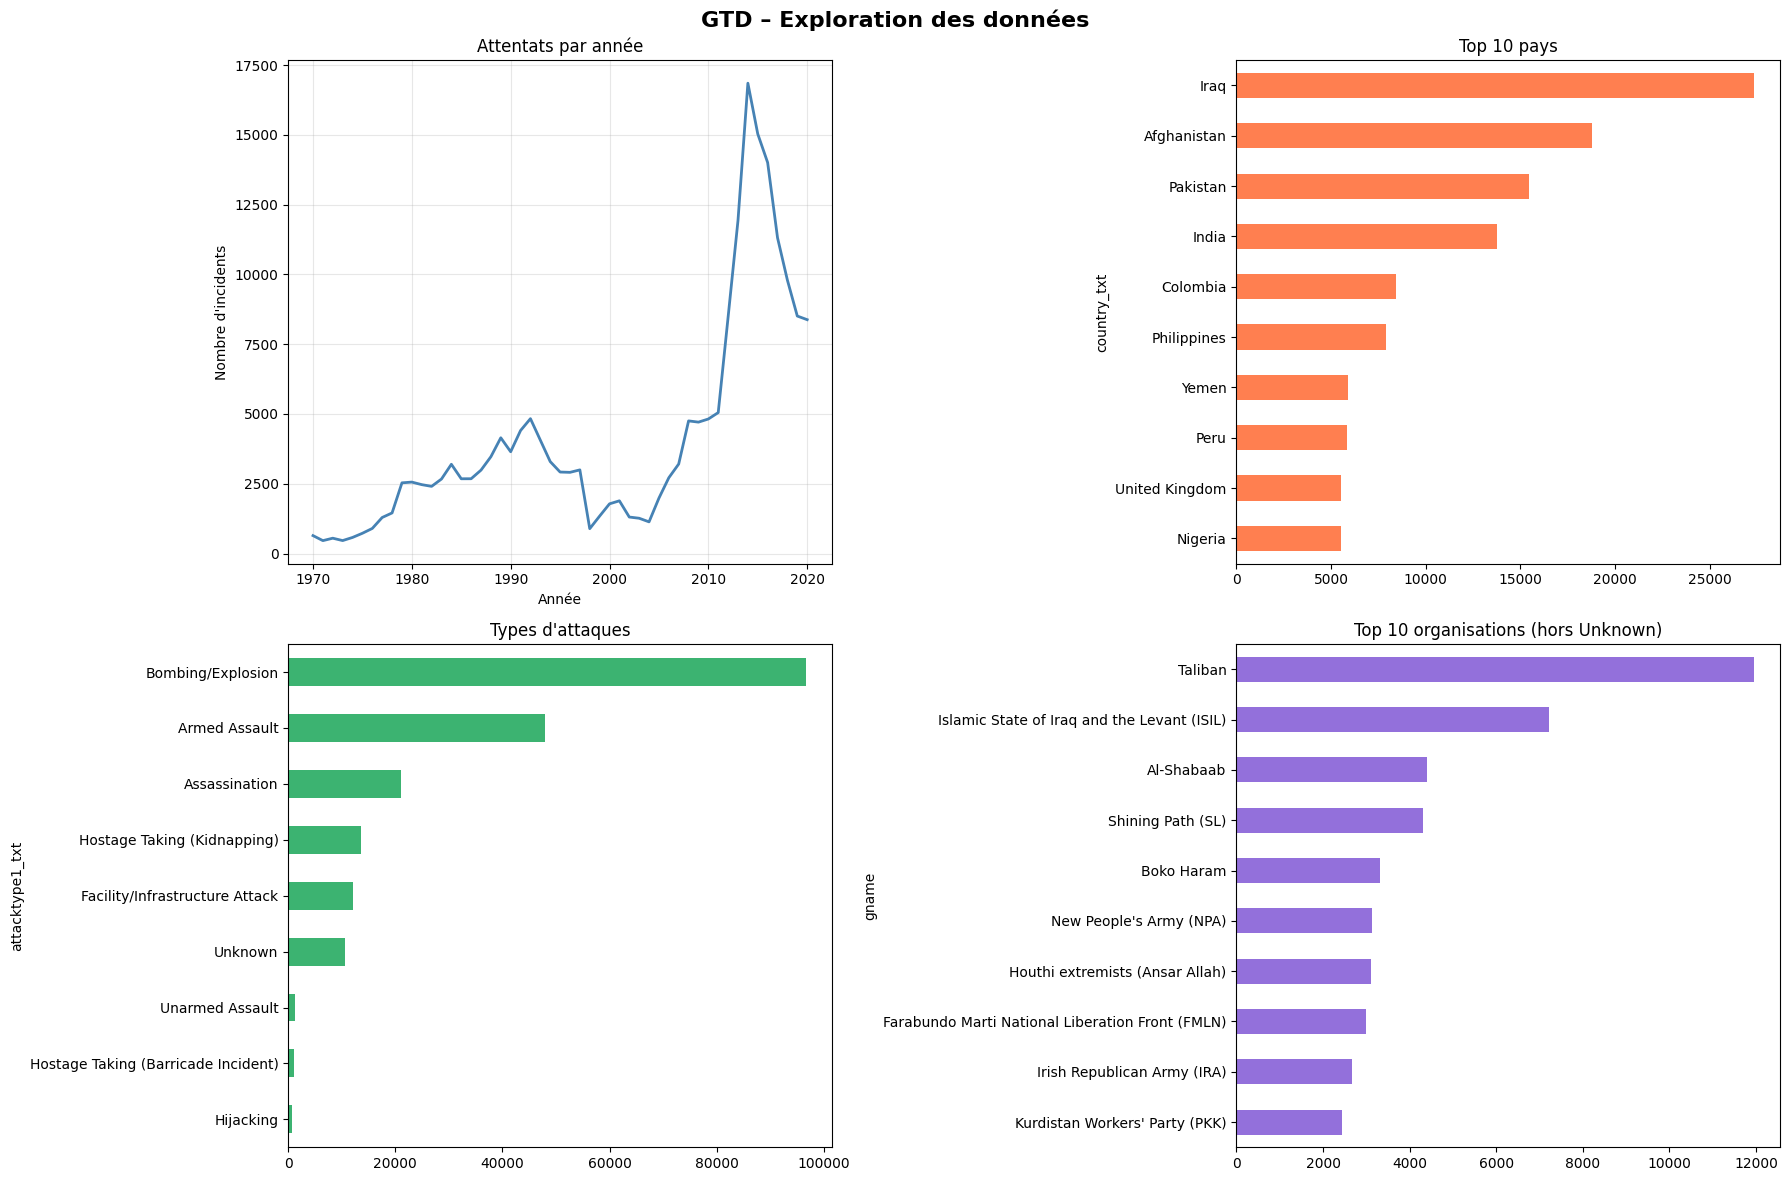

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("GTD – Exploration des données", fontsize=16, fontweight="bold")

# Évolution temporelle
df.groupby("iyear").size().plot(ax=axes[0,0], color="steelblue", linewidth=2)
axes[0,0].set_title("Attentats par année")
axes[0,0].set_xlabel("Année")
axes[0,0].set_ylabel("Nombre d'incidents")
axes[0,0].grid(alpha=0.3)

# Top 10 pays
df["country_txt"].value_counts().head(10).plot(kind="barh", ax=axes[0,1], color="coral")
axes[0,1].set_title("Top 10 pays")
axes[0,1].invert_yaxis()

# Types d'attaques — barres horizontales pour éviter le chevauchement
df["attacktype1_txt"].value_counts().plot(kind="barh", ax=axes[1,0], color="mediumseagreen")
axes[1,0].set_title("Types d'attaques")
axes[1,0].invert_yaxis()

# Top 10 organisations (sans Unknown)
df[df["gname"] != "Unknown"]["gname"].value_counts().head(10).plot(kind="barh", ax=axes[1,1], color="mediumpurple")
axes[1,1].set_title("Top 10 organisations (hors Unknown)")
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig("../outputs/gtd_exploration.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
import folium
from folium.plugins import HeatMap

# Échantillon de 15 000 points pour ne pas surcharger la carte
sample = df[["latitude", "longitude"]].sample(n=15000, random_state=42)

# Création de la carte
carte = folium.Map(location=[20, 0], zoom_start=2, tiles="CartoDB dark_matter")

# Ajout de la heatmap
HeatMap(
    sample.values.tolist(),
    radius=5,
    blur=8,
    min_opacity=0.3
).add_to(carte)

# Sauvegarde
carte.save("../outputs/gtd_heatmap.html")
print("Carte sauvegardée dans outputs/gtd_heatmap.html !")

Carte sauvegardée dans outputs/gtd_heatmap.html !


In [11]:
import folium
from folium.plugins import HeatMap
import json

# Préparer les données par année
années = sorted(df["iyear"].unique().tolist())
types = sorted(df["attacktype1_txt"].unique().tolist())
régions = sorted(df["region_txt"].unique().tolist())

# Construire le dictionnaire de données pour le JS
data_by_year = {}
for année in années:
    subset = df[df["iyear"] == année][["latitude", "longitude"]].dropna()
    data_by_year[int(année)] = subset.values.tolist()

data_by_type = {}
for t in types:
    subset = df[df["attacktype1_txt"] == t][["latitude", "longitude"]].dropna()
    data_by_type[t] = subset.values.tolist()

data_by_region = {}
for r in régions:
    subset = df[df["region_txt"] == r][["latitude", "longitude"]].dropna()
    data_by_region[r] = subset.values.tolist()

# Carte de base
carte = folium.Map(location=[20, 0], zoom_start=2, tiles="CartoDB dark_matter")

# HTML + JS pour les filtres
html_control = f"""
<div id="controls" style="
    position: fixed;
    top: 20px; left: 50%;
    transform: translateX(-50%);
    z-index: 9999;
    background: rgba(20,20,20,0.92);
    padding: 14px 20px;
    border-radius: 12px;
    color: white;
    font-family: Arial, sans-serif;
    font-size: 13px;
    display: flex;
    gap: 20px;
    align-items: center;
    box-shadow: 0 4px 20px rgba(0,0,0,0.5);
">
    <div>
        <label>Filtre</label><br>
        <select id="filterType" onchange="updateMap()" style="background:#333;color:white;border:1px solid #555;border-radius:6px;padding:4px 8px;margin-top:4px;">
            <option value="year">Par année</option>
            <option value="type">Par type d'attaque</option>
            <option value="region">Par région</option>
        </select>
    </div>
    <div id="yearControl">
        <label>Année : <span id="yearLabel">{années[0]}</span></label><br>
        <input type="range" id="yearSlider" min="{années[0]}" max="{années[-1]}" value="{années[0]}"
            oninput="document.getElementById('yearLabel').textContent=this.value; updateMap()"
            style="width:220px;margin-top:6px;">
    </div>
    <div id="typeControl" style="display:none;">
        <label>Type d'attaque</label><br>
        <select id="typeSelect" onchange="updateMap()" style="background:#333;color:white;border:1px solid #555;border-radius:6px;padding:4px 8px;margin-top:4px;max-width:200px;">
            {''.join(f'<option value="{t}">{t}</option>' for t in types)}
        </select>
    </div>
    <div id="regionControl" style="display:none;">
        <label>Région</label><br>
        <select id="regionSelect" onchange="updateMap()" style="background:#333;color:white;border:1px solid #555;border-radius:6px;padding:4px 8px;margin-top:4px;max-width:200px;">
            {''.join(f'<option value="{r}">{r}</option>' for r in régions)}
        </select>
    </div>
    <div>
        <label>Incidents</label><br>
        <span id="countLabel" style="font-size:18px;font-weight:bold;color:#ff6b6b;">—</span>
    </div>
</div>

<script>
var dataByYear    = {json.dumps(data_by_year)};
var dataByType    = {json.dumps(data_by_type)};
var dataByRegion  = {json.dumps(data_by_region)};
var heatLayer     = null;

function updateMap() {{
    var filterType = document.getElementById("filterType").value;

    document.getElementById("yearControl").style.display   = filterType === "year"   ? "block" : "none";
    document.getElementById("typeControl").style.display   = filterType === "type"   ? "block" : "none";
    document.getElementById("regionControl").style.display = filterType === "region" ? "block" : "none";

    var points = [];
    if (filterType === "year") {{
        var year = parseInt(document.getElementById("yearSlider").value);
        points = dataByYear[year] || [];
    }} else if (filterType === "type") {{
        var type = document.getElementById("typeSelect").value;
        points = dataByType[type] || [];
    }} else if (filterType === "region") {{
        var region = document.getElementById("regionSelect").value;
        points = dataByRegion[region] || [];
    }}

    document.getElementById("countLabel").textContent = points.length.toLocaleString();

    if (heatLayer) {{ map_{carte._id}.removeLayer(heatLayer); }}
    heatLayer = L.heatLayer(points, {{radius: 5, blur: 8, minOpacity: 0.3}}).addTo(map_{carte._id});
}}

window.onload = function() {{ updateMap(); }};
</script>
"""

carte.get_root().html.add_child(folium.Element(html_control))
carte.save("../outputs/gtd_heatmap_interactive.html")
print("Carte interactive sauvegardée dans outputs/gtd_heatmap_interactive.html !")

Carte interactive sauvegardée dans outputs/gtd_heatmap_interactive.html !


In [12]:
import folium
from folium.plugins import HeatMap
import json

# Préparer les données
années = sorted(df["iyear"].unique().tolist())
types = sorted(df["attacktype1_txt"].unique().tolist())
régions = sorted(df["region_txt"].unique().tolist())

data_by_year = {}
for année in années:
    subset = df[df["iyear"] == année][["latitude", "longitude"]].dropna()
    data_by_year[int(année)] = subset.values.tolist()

data_by_type = {}
for t in types:
    subset = df[df["attacktype1_txt"] == t][["latitude", "longitude"]].dropna()
    data_by_type[t] = subset.values.tolist()

data_by_region = {}
for r in régions:
    subset = df[df["region_txt"] == r][["latitude", "longitude"]].dropna()
    data_by_region[r] = subset.values.tolist()

# Carte de base
carte = folium.Map(location=[20, 0], zoom_start=2, tiles="CartoDB dark_matter")

# Ajouter le plugin leaflet.heat manuellement
carte.get_root().header.add_child(folium.Element(
    '<script src="https://cdn.jsdelivr.net/npm/leaflet.heat@0.2.0/dist/leaflet-heat.js"></script>'
))

map_id = carte.get_name()

html_control = f"""
<div id="controls" style="
    position: fixed;
    top: 20px; left: 50%;
    transform: translateX(-50%);
    z-index: 9999;
    background: rgba(20,20,20,0.92);
    padding: 14px 20px;
    border-radius: 12px;
    color: white;
    font-family: Arial, sans-serif;
    font-size: 13px;
    display: flex;
    gap: 20px;
    align-items: center;
    box-shadow: 0 4px 20px rgba(0,0,0,0.5);
">
    <div>
        <label>Filtre</label><br>
        <select id="filterType" onchange="updateMap()" style="background:#333;color:white;border:1px solid #555;border-radius:6px;padding:4px 8px;margin-top:4px;">
            <option value="year">Par plage d'années</option>
            <option value="type">Par type d'attaque</option>
            <option value="region">Par région</option>
        </select>
    </div>

    <div id="yearControl">
        <label>De <span id="yearStartLabel">{années[0]}</span> à <span id="yearEndLabel">{années[-1]}</span></label><br>
        <div style="display:flex;gap:10px;align-items:center;margin-top:6px;">
            <input type="range" id="yearStart" min="{années[0]}" max="{années[-1]}" value="{années[0]}"
                oninput="
                    if(parseInt(this.value) > parseInt(document.getElementById('yearEnd').value))
                        document.getElementById('yearEnd').value = this.value;
                    document.getElementById('yearStartLabel').textContent = this.value;
                    updateMap();"
                style="width:140px;">
            <input type="range" id="yearEnd" min="{années[0]}" max="{années[-1]}" value="{années[-1]}"
                oninput="
                    if(parseInt(this.value) < parseInt(document.getElementById('yearStart').value))
                        document.getElementById('yearStart').value = this.value;
                    document.getElementById('yearEndLabel').textContent = this.value;
                    updateMap();"
                style="width:140px;">
        </div>
    </div>

    <div id="typeControl" style="display:none;">
        <label>Type d'attaque</label><br>
        <select id="typeSelect" onchange="updateMap()" style="background:#333;color:white;border:1px solid #555;border-radius:6px;padding:4px 8px;margin-top:4px;max-width:200px;">
            {''.join(f'<option value="{t}">{t}</option>' for t in types)}
        </select>
    </div>

    <div id="regionControl" style="display:none;">
        <label>Région</label><br>
        <select id="regionSelect" onchange="updateMap()" style="background:#333;color:white;border:1px solid #555;border-radius:6px;padding:4px 8px;margin-top:4px;max-width:200px;">
            {''.join(f'<option value="{r}">{r}</option>' for r in régions)}
        </select>
    </div>

    <div>
        <label>Incidents</label><br>
        <span id="countLabel" style="font-size:18px;font-weight:bold;color:#ff6b6b;">—</span>
    </div>
</div>

<script>
var dataByYear   = {json.dumps(data_by_year)};
var dataByType   = {json.dumps(data_by_type)};
var dataByRegion = {json.dumps(data_by_region)};
var heatLayer    = null;
var mapObj       = window["{map_id}"];

function updateMap() {{
    var filterType = document.getElementById("filterType").value;

    document.getElementById("yearControl").style.display   = filterType === "year"   ? "block" : "none";
    document.getElementById("typeControl").style.display   = filterType === "type"   ? "block" : "none";
    document.getElementById("regionControl").style.display = filterType === "region" ? "block" : "none";

    var points = [];

    if (filterType === "year") {{
        var start = parseInt(document.getElementById("yearStart").value);
        var end   = parseInt(document.getElementById("yearEnd").value);
        for (var y = start; y <= end; y++) {{
            if (dataByYear[y]) points = points.concat(dataByYear[y]);
        }}
    }} else if (filterType === "type") {{
        var type = document.getElementById("typeSelect").value;
        points = dataByType[type] || [];
    }} else if (filterType === "region") {{
        var region = document.getElementById("regionSelect").value;
        points = dataByRegion[region] || [];
    }}

    document.getElementById("countLabel").textContent = points.length.toLocaleString();

    if (!mapObj) mapObj = window["{map_id}"];
    if (heatLayer) {{ mapObj.removeLayer(heatLayer); }}
    heatLayer = L.heatLayer(points, {{radius: 5, blur: 8, minOpacity: 0.3}}).addTo(mapObj);
}}

setTimeout(function() {{ updateMap(); }}, 500);
</script>
"""

carte.get_root().html.add_child(folium.Element(html_control))
carte.save("../outputs/gtd_heatmap_interactive.html")
print("Carte interactive sauvegardée dans outputs/gtd_heatmap_interactive.html !")

Carte interactive sauvegardée dans outputs/gtd_heatmap_interactive.html !


In [13]:
import folium
from folium.plugins import HeatMap
import json

années = sorted(df["iyear"].unique().tolist())
types = sorted(df["attacktype1_txt"].unique().tolist())
régions = sorted(df["region_txt"].unique().tolist())

data_by_year = {}
for année in années:
    subset = df[df["iyear"] == année][["latitude", "longitude"]].dropna()
    data_by_year[int(année)] = subset.values.tolist()

data_by_type = {}
for t in types:
    subset = df[df["attacktype1_txt"] == t][["latitude", "longitude"]].dropna()
    data_by_type[t] = subset.values.tolist()

data_by_region = {}
for r in régions:
    subset = df[df["region_txt"] == r][["latitude", "longitude"]].dropna()
    data_by_region[r] = subset.values.tolist()

# On crée une heatmap par année et on les empile dans la carte
carte = folium.Map(location=[20, 0], zoom_start=2, tiles="CartoDB dark_matter")

# On ajoute toutes les années comme layers séparés
for année in années:
    points = data_by_year[int(année)]
    if points:
        HeatMap(
            points,
            name=str(année),
            radius=5,
            blur=8,
            min_opacity=0.3,
            show=(année == années[-1])  # affiche seulement la dernière année par défaut
        ).add_to(carte)

# Contrôle des layers natif folium
folium.LayerControl(collapsed=False).add_to(carte)

carte.save("../outputs/gtd_heatmap_interactive.html")
print("Carte sauvegardée !")

Carte sauvegardée !


In [14]:
import folium
from folium.plugins import HeatMap
import ipywidgets as widgets
from IPython.display import display, HTML
import json

années = sorted(df["iyear"].unique().tolist())

# Widgets
start_widget = widgets.Dropdown(
    options=années,
    value=années[0],
    description="De :",
)
end_widget = widgets.Dropdown(
    options=années,
    value=années[-1],
    description="À :",
)
type_widget = widgets.Dropdown(
    options=["Tous"] + sorted(df["attacktype1_txt"].unique().tolist()),
    value="Tous",
    description="Type :",
)
region_widget = widgets.Dropdown(
    options=["Toutes"] + sorted(df["region_txt"].unique().tolist()),
    value="Toutes",
    description="Région :",
)
output = widgets.Output()

def update_map(change=None):
    start = start_widget.value
    end   = end_widget.value

    if start > end:
        end_widget.value = start
        return

    subset = df[(df["iyear"] >= start) & (df["iyear"] <= end)]

    if type_widget.value != "Tous":
        subset = subset[subset["attacktype1_txt"] == type_widget.value]

    if region_widget.value != "Toutes":
        subset = subset[subset["region_txt"] == region_widget.value]

    subset = subset[["latitude", "longitude"]].dropna()

    carte = folium.Map(location=[20, 0], zoom_start=2, tiles="CartoDB dark_matter")
    if len(subset) > 0:
        HeatMap(subset.values.tolist(), radius=5, blur=8, min_opacity=0.3).add_to(carte)

    with output:
        output.clear_output(wait=True)
        display(HTML(f"<b>{len(subset):,} incidents affichés</b>"))
        display(carte)

    carte.save("../outputs/gtd_heatmap_interactive.html")

start_widget.observe(update_map, names="value")
end_widget.observe(update_map, names="value")
type_widget.observe(update_map, names="value")
region_widget.observe(update_map, names="value")

display(widgets.HBox([start_widget, end_widget, type_widget, region_widget]))
display(output)
update_map()

Output()

In [15]:
import folium
from folium.plugins import HeatMap
import ipywidgets as widgets
from IPython.display import display, HTML

années = sorted(df["iyear"].unique().tolist())

start_widget = widgets.Dropdown(
    options=années, value=années[0], description="De :"
)
end_widget = widgets.Dropdown(
    options=années, value=années[-1], description="À :"
)
type_widget = widgets.Dropdown(
    options=["Tous"] + sorted(df["attacktype1_txt"].unique().tolist()),
    value="Tous", description="Type :"
)
region_widget = widgets.Dropdown(
    options=["Toutes"] + sorted(df["region_txt"].unique().tolist()),
    value="Toutes", description="Région :"
)
orga_widget = widgets.Dropdown(
    options=["Toutes"] + sorted(df["gname"].unique().tolist()),
    value="Toutes", description="Organisation :"
)
output = widgets.Output()

def update_map(change=None):
    start = start_widget.value
    end   = end_widget.value

    if start > end:
        end_widget.value = start
        return

    subset = df[(df["iyear"] >= start) & (df["iyear"] <= end)]

    if type_widget.value != "Tous":
        subset = subset[subset["attacktype1_txt"] == type_widget.value]

    if region_widget.value != "Toutes":
        subset = subset[subset["region_txt"] == region_widget.value]

    if orga_widget.value != "Toutes":
        subset = subset[subset["gname"] == orga_widget.value]

    subset = subset[["latitude", "longitude"]].dropna()

    carte = folium.Map(location=[20, 0], zoom_start=2, tiles="CartoDB dark_matter")
    if len(subset) > 0:
        HeatMap(subset.values.tolist(), radius=5, blur=8, min_opacity=0.3).add_to(carte)

    with output:
        output.clear_output(wait=True)
        display(HTML(f"<b>{len(subset):,} incidents affichés</b>"))
        display(carte)

    carte.save("../outputs/gtd_heatmap_interactive.html")

start_widget.observe(update_map, names="value")
end_widget.observe(update_map, names="value")
type_widget.observe(update_map, names="value")
region_widget.observe(update_map, names="value")
orga_widget.observe(update_map, names="value")

display(widgets.HBox([start_widget, end_widget]))
display(widgets.HBox([type_widget, region_widget, orga_widget]))
display(output)
update_map()

Output()

In [16]:
# Chargement du fichier complémentaire 2021
df_2021 = pd.read_excel("../data/globalterrorismdb_2021Jan-June_1222dist.xlsx", engine="openpyxl")

print(f"Fichier 2021 — Lignes : {len(df_2021):,} | Colonnes : {df_2021.shape[1]}")

# On garde uniquement les mêmes colonnes que df
cols_disponibles = [c for c in COLONNES_UTILES if c in df_2021.columns]
df_2021 = df_2021[cols_disponibles].copy()

# Fusion des deux DataFrames
df = pd.concat([df, df_2021], ignore_index=True)

# On réapplique le nettoyage
df = df.dropna(subset=["latitude", "longitude"])
df["nkill"]  = df["nkill"].fillna(0).clip(lower=0)
df["nwound"] = df["nwound"].fillna(0).clip(lower=0)

print(f"\nAprès fusion et nettoyage :")
print(f"Lignes totales : {len(df):,}")
print(f"Période : {df['iyear'].min()} – {df['iyear'].max()}")

Fichier 2021 — Lignes : 4,960 | Colonnes : 135

Après fusion et nettoyage :
Lignes totales : 209,939
Période : 1970 – 2021


In [17]:
import folium
from folium.plugins import HeatMap
import ipywidgets as widgets
from IPython.display import display, HTML

années = sorted(df["iyear"].unique().tolist())

start_widget = widgets.Dropdown(
    options=années, value=années[0], description="De :"
)
end_widget = widgets.Dropdown(
    options=années, value=années[-1], description="À :"
)
type_widget = widgets.Dropdown(
    options=["Tous"] + sorted(df["attacktype1_txt"].unique().tolist()),
    value="Tous", description="Type :"
)
region_widget = widgets.Dropdown(
    options=["Toutes"] + sorted(df["region_txt"].unique().tolist()),
    value="Toutes", description="Région :"
)
orga_widget = widgets.Dropdown(
    options=["Toutes"] + sorted(df["gname"].unique().tolist()),
    value="Toutes", description="Organisation :"
)
output = widgets.Output()

def update_map(change=None):
    start = start_widget.value
    end   = end_widget.value

    if start > end:
        end_widget.value = start
        return

    subset = df[(df["iyear"] >= start) & (df["iyear"] <= end)]

    if type_widget.value != "Tous":
        subset = subset[subset["attacktype1_txt"] == type_widget.value]

    if region_widget.value != "Toutes":
        subset = subset[subset["region_txt"] == region_widget.value]

    if orga_widget.value != "Toutes":
        subset = subset[subset["gname"] == orga_widget.value]

    subset = subset[["latitude", "longitude"]].dropna()

    carte = folium.Map(location=[20, 0], zoom_start=2, tiles="CartoDB dark_matter")
    if len(subset) > 0:
        HeatMap(subset.values.tolist(), radius=5, blur=8, min_opacity=0.3).add_to(carte)

    with output:
        output.clear_output(wait=True)
        display(HTML(f"<b>{len(subset):,} incidents affichés</b>"))
        display(carte)

    carte.save("../outputs/gtd_heatmap_interactive.html")

start_widget.observe(update_map, names="value")
end_widget.observe(update_map, names="value")
type_widget.observe(update_map, names="value")
region_widget.observe(update_map, names="value")
orga_widget.observe(update_map, names="value")

display(widgets.HBox([start_widget, end_widget]))
display(widgets.HBox([type_widget, region_widget, orga_widget]))
display(output)
update_map()

Output()

In [18]:
TAILLE_CELLULE = 1.0  # 1° x 1° soit environ 111km x 111km à l'équateur

df["cell_lat"] = (df["latitude"]  // TAILLE_CELLULE) * TAILLE_CELLULE
df["cell_lon"] = (df["longitude"] // TAILLE_CELLULE) * TAILLE_CELLULE
df["cell_id"]  = df["cell_lat"].astype(str) + "_" + df["cell_lon"].astype(str)

print(f"Nombre de cellules distinctes : {df['cell_id'].nunique():,}")
print(f"\nTop 10 cellules les plus actives :")
print(df["cell_id"].value_counts().head(10))

Nombre de cellules distinctes : 4,085

Top 10 cellules les plus actives :
cell_id
33.0_44.0      12797
6.0_101.0       3379
34.0_71.0       3115
24.0_67.0       2782
36.0_43.0       2676
2.0_45.0        2576
13.0_-90.0      2518
54.0_-6.0       2511
-12.0_-77.0     2446
31.0_34.0       2435
Name: count, dtype: int64


In [19]:
# Agrégation par cellule et par année
grid = df.groupby(["cell_id", "cell_lat", "cell_lon", "iyear"]).agg(
    nb_incidents = ("eventid", "count"),
    nb_morts     = ("nkill", "sum"),
    nb_blesses   = ("nwound", "sum"),
    nb_succes    = ("success", "sum"),
    nb_suicide   = ("suicide", "sum"),
).reset_index()

# Variable cible : 1 si au moins un incident, 0 sinon
grid["target"] = (grid["nb_incidents"] > 0).astype(int)

print(f"Taille de la grille : {len(grid):,} lignes")
print(f"\nAperçu :")
print(grid.head(10))
print(f"\nDistribution de la variable cible :")
print(grid["target"].value_counts())

Taille de la grille : 26,858 lignes

Aperçu :
      cell_id  cell_lat  cell_lon  iyear  nb_incidents  nb_morts  nb_blesses  \
0  -1.0_-71.0      -1.0     -71.0   2017             1       0.0         0.0   
1  -1.0_-73.0      -1.0     -73.0   2014             1       2.0         2.0   
2  -1.0_-75.0      -1.0     -75.0   2018             1       1.0         0.0   
3  -1.0_-76.0      -1.0     -76.0   2012             1       0.0         0.0   
4  -1.0_-76.0      -1.0     -76.0   2016             1       0.0         0.0   
5  -1.0_-77.0      -1.0     -77.0   1994             1       0.0         0.0   
6  -1.0_-77.0      -1.0     -77.0   1999             1       0.0         0.0   
7  -1.0_-77.0      -1.0     -77.0   2000             1       0.0         0.0   
8  -1.0_-78.0      -1.0     -78.0   1984             1       0.0         0.0   
9  -1.0_-78.0      -1.0     -78.0   1988             1       2.0         1.0   

   nb_succes  nb_suicide  target  
0          1           0       1  
1  

In [20]:
import numpy as np

# Créer toutes les combinaisons possibles cellule x année
toutes_les_annees = range(df["iyear"].min(), df["iyear"].max() + 1)
toutes_les_cellules = df[["cell_id", "cell_lat", "cell_lon"]].drop_duplicates()

# Produit cartésien cellules x années
index_complet = toutes_les_cellules.merge(
    pd.DataFrame({"iyear": toutes_les_annees}), how="cross"
)

# Fusion avec la grille existante
grid = index_complet.merge(grid, on=["cell_id", "cell_lat", "cell_lon", "iyear"], how="left")

# Remplir les NaN par 0 (pas d'incident = 0)
grid["nb_incidents"] = grid["nb_incidents"].fillna(0).astype(int)
grid["nb_morts"]     = grid["nb_morts"].fillna(0)
grid["nb_blesses"]   = grid["nb_blesses"].fillna(0)
grid["nb_succes"]    = grid["nb_succes"].fillna(0)
grid["nb_suicide"]   = grid["nb_suicide"].fillna(0)
grid["target"]       = grid["target"].fillna(0).astype(int)

print(f"Taille de la grille complète : {len(grid):,} lignes")
print(f"\nDistribution de la variable cible :")
print(grid["target"].value_counts())
print(f"\nPourcentage de cellules actives : {grid['target'].mean()*100:.1f}%")

Taille de la grille complète : 212,420 lignes

Distribution de la variable cible :
target
0    185562
1     26858
Name: count, dtype: int64

Pourcentage de cellules actives : 12.6%


In [21]:
# Features temporelles et spatiales
grid = grid.sort_values(["cell_id", "iyear"]).reset_index(drop=True)

# Historique : incidents de l'année précédente
grid["incidents_annee_precedente"] = grid.groupby("cell_id")["nb_incidents"].shift(1).fillna(0)

# Moyenne glissante sur 3 ans
grid["moyenne_3ans"] = grid.groupby("cell_id")["nb_incidents"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0)

# Moyenne glissante sur 5 ans
grid["moyenne_5ans"] = grid.groupby("cell_id")["nb_incidents"].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(0)

# Nombre d'années actives dans le passé
grid["nb_annees_actives"] = grid.groupby("cell_id")["target"].transform(
    lambda x: x.shift(1).expanding().sum()
).fillna(0)

print("Features créées avec succès !")
print(grid[["cell_id", "iyear", "nb_incidents", "incidents_annee_precedente", 
            "moyenne_3ans", "moyenne_5ans", "nb_annees_actives", "target"]].head(15))

Features créées avec succès !
       cell_id  iyear  nb_incidents  incidents_annee_precedente  moyenne_3ans  \
0   -1.0_-71.0   1970             0                         0.0           0.0   
1   -1.0_-71.0   1971             0                         0.0           0.0   
2   -1.0_-71.0   1972             0                         0.0           0.0   
3   -1.0_-71.0   1973             0                         0.0           0.0   
4   -1.0_-71.0   1974             0                         0.0           0.0   
5   -1.0_-71.0   1975             0                         0.0           0.0   
6   -1.0_-71.0   1976             0                         0.0           0.0   
7   -1.0_-71.0   1977             0                         0.0           0.0   
8   -1.0_-71.0   1978             0                         0.0           0.0   
9   -1.0_-71.0   1979             0                         0.0           0.0   
10  -1.0_-71.0   1980             0                         0.0           0.0  

In [22]:
# Features temporelles et spatiales
grid = grid.sort_values(["cell_id", "iyear"]).reset_index(drop=True).copy()

# Historique : incidents de l'année précédente
grid["incidents_annee_precedente"] = (
    grid.groupby("cell_id")["nb_incidents"]
    .shift(1)
    .fillna(0)
)

# Moyenne glissante sur 3 ans
grid["moyenne_3ans"] = (
    grid.groupby("cell_id")["nb_incidents"]
    .shift(1)
    .groupby(grid["cell_id"])
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
    .fillna(0)
)

# Moyenne glissante sur 5 ans
grid["moyenne_5ans"] = (
    grid.groupby("cell_id")["nb_incidents"]
    .shift(1)
    .groupby(grid["cell_id"])
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
    .fillna(0)
)

# Nombre d'années actives dans le passé
grid["nb_annees_actives"] = (
    grid.groupby("cell_id")["target"]
    .shift(1)
    .fillna(0)
    .groupby(grid["cell_id"])
    .transform(lambda x: x.expanding().sum())
)

print("Features créées avec succès !")
print(grid[["cell_id", "iyear", "nb_incidents", "incidents_annee_precedente",
            "moyenne_3ans", "moyenne_5ans", "nb_annees_actives", "target"]].head(15))

Features créées avec succès !
       cell_id  iyear  nb_incidents  incidents_annee_precedente  moyenne_3ans  \
0   -1.0_-71.0   1970             0                         0.0           0.0   
1   -1.0_-71.0   1971             0                         0.0           0.0   
2   -1.0_-71.0   1972             0                         0.0           0.0   
3   -1.0_-71.0   1973             0                         0.0           0.0   
4   -1.0_-71.0   1974             0                         0.0           0.0   
5   -1.0_-71.0   1975             0                         0.0           0.0   
6   -1.0_-71.0   1976             0                         0.0           0.0   
7   -1.0_-71.0   1977             0                         0.0           0.0   
8   -1.0_-71.0   1978             0                         0.0           0.0   
9   -1.0_-71.0   1979             0                         0.0           0.0   
10  -1.0_-71.0   1980             0                         0.0           0.0  

In [23]:
# Sauvegarde de la grille
grid.to_csv("../data/grid_features.csv", index=False)
print("Grille sauvegardée dans data/grid_features.csv !")

# Définition des features et de la cible
FEATURES = [
    "cell_lat",
    "cell_lon",
    "iyear",
    "incidents_annee_precedente",
    "moyenne_3ans",
    "moyenne_5ans",
    "nb_annees_actives",
]

X = grid[FEATURES]
y = grid["target"]

# Séparation train / test
# On entraîne sur 1970-2015, on teste sur 2016-2021
train = grid[grid["iyear"] <= 2015]
test  = grid[grid["iyear"] >  2015]

X_train = train[FEATURES]
y_train = train["target"]
X_test  = test[FEATURES]
y_test  = test["target"]

print(f"\nTrain : {len(X_train):,} lignes ({train['iyear'].min()}–{train['iyear'].max()})")
print(f"Test  : {len(X_test):,} lignes ({test['iyear'].min()}–{test['iyear'].max()})")
print(f"\nTaux de positifs train : {y_train.mean()*100:.1f}%")
print(f"Taux de positifs test  : {y_test.mean()*100:.1f}%")

Grille sauvegardée dans data/grid_features.csv !

Train : 187,910 lignes (1970–2015)
Test  : 24,510 lignes (2016–2021)

Taux de positifs train : 11.0%
Taux de positifs test  : 25.4%


In [24]:
# Features supplémentaires - type d'attaque dominant par cellule
type_dominant = df.groupby(["cell_id", "iyear"])["attacktype1_txt"].agg(
    lambda x: x.value_counts().index[0]
).reset_index()
type_dominant.columns = ["cell_id", "iyear", "type_dominant"]

# Encodage du type dominant
type_categories = sorted(df["attacktype1_txt"].unique().tolist())
type_map = {t: i for i, t in enumerate(type_categories)}
type_dominant["type_dominant_code"] = type_dominant["type_dominant"].map(type_map)

# Organisation dominante par cellule
orga_dominant = df.groupby(["cell_id", "iyear"])["gname"].agg(
    lambda x: x.value_counts().index[0]
).reset_index()
orga_dominant.columns = ["cell_id", "iyear", "orga_dominant"]
orga_categories = sorted(df["gname"].unique().tolist())
orga_map = {o: i for i, o in enumerate(orga_categories)}
orga_dominant["orga_dominant_code"] = orga_dominant["gname"].map(orga_map) if "gname" in orga_dominant.columns else orga_dominant["orga_dominant"].map(orga_map)

# Fusion avec la grille
grid = grid.merge(type_dominant[["cell_id", "iyear", "type_dominant_code"]], on=["cell_id", "iyear"], how="left")
grid = grid.merge(orga_dominant[["cell_id", "iyear", "orga_dominant_code"]], on=["cell_id", "iyear"], how="left")
grid["type_dominant_code"] = grid["type_dominant_code"].fillna(-1).astype(int)
grid["orga_dominant_code"] = grid["orga_dominant_code"].fillna(-1).astype(int)

print("Features supplémentaires ajoutées !")
print(grid.shape)

Features supplémentaires ajoutées !
(212420, 16)


In [25]:
FEATURES = [
    "cell_lat",
    "cell_lon",
    "iyear",
    "incidents_annee_precedente",
    "moyenne_3ans",
    "moyenne_5ans",
    "nb_annees_actives",
    "type_dominant_code",
    "orga_dominant_code",
]

train = grid[grid["iyear"] <= 2015]
test  = grid[grid["iyear"] >  2015]

X_train = train[FEATURES]
y_train = train["target"]
X_test  = test[FEATURES]
y_test  = test["target"]

print(f"Train : {len(X_train):,} lignes ({train['iyear'].min()}–{train['iyear'].max()})")
print(f"Test  : {len(X_test):,} lignes ({test['iyear'].min()}–{test['iyear'].max()})")

Train : 187,910 lignes (1970–2015)
Test  : 24,510 lignes (2016–2021)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Modèle
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Évaluation
y_pred_lr  = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== RÉGRESSION LOGISTIQUE ===")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_lr):.4f}")

=== RÉGRESSION LOGISTIQUE ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18293
           1       1.00      1.00      1.00      6217

    accuracy                           1.00     24510
   macro avg       1.00      1.00      1.00     24510
weighted avg       1.00      1.00      1.00     24510

AUC-ROC : 1.0000


In [27]:
# Correction du data leakage - décaler d'un an
type_dominant = type_dominant.copy()
type_dominant["iyear"] = type_dominant["iyear"] + 1  # on décale d'un an
type_dominant.rename(columns={"type_dominant_code": "type_dominant_code_lag"}, inplace=True)

orga_dominant = orga_dominant.copy()
orga_dominant["iyear"] = orga_dominant["iyear"] + 1
orga_dominant.rename(columns={"orga_dominant_code": "orga_dominant_code_lag"}, inplace=True)

# Retirer les anciennes colonnes et refusionner
grid = grid.drop(columns=["type_dominant_code", "orga_dominant_code"], errors="ignore")
grid = grid.merge(type_dominant[["cell_id", "iyear", "type_dominant_code_lag"]], on=["cell_id", "iyear"], how="left")
grid = grid.merge(orga_dominant[["cell_id", "iyear", "orga_dominant_code_lag"]], on=["cell_id", "iyear"], how="left")
grid["type_dominant_code_lag"] = grid["type_dominant_code_lag"].fillna(-1).astype(int)
grid["orga_dominant_code_lag"] = grid["orga_dominant_code_lag"].fillna(-1).astype(int)

# Mise à jour des features
FEATURES = [
    "cell_lat",
    "cell_lon",
    "iyear",
    "incidents_annee_precedente",
    "moyenne_3ans",
    "moyenne_5ans",
    "nb_annees_actives",
    "type_dominant_code_lag",
    "orga_dominant_code_lag",
]

train = grid[grid["iyear"] <= 2015]
test  = grid[grid["iyear"] >  2015]

X_train = train[FEATURES]
y_train = train["target"]
X_test  = test[FEATURES]
y_test  = test["target"]

# Régression logistique
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr  = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== RÉGRESSION LOGISTIQUE (corrigée) ===")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_lr):.4f}")

=== RÉGRESSION LOGISTIQUE (corrigée) ===
              precision    recall  f1-score   support

           0       0.91      0.65      0.76     18293
           1       0.44      0.80      0.57      6217

    accuracy                           0.69     24510
   macro avg       0.67      0.73      0.67     24510
weighted avg       0.79      0.69      0.71     24510

AUC-ROC : 0.8124


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_rf):.4f}")

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.87      0.91      0.89     18293
           1       0.68      0.60      0.64      6217

    accuracy                           0.83     24510
   macro avg       0.78      0.75      0.76     24510
weighted avg       0.82      0.83      0.82     24510

AUC-ROC : 0.8358


In [29]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBOOST ===")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_xgb):.4f}")

=== XGBOOST ===
              precision    recall  f1-score   support

           0       0.93      0.58      0.72     18293
           1       0.42      0.87      0.56      6217

    accuracy                           0.66     24510
   macro avg       0.67      0.73      0.64     24510
weighted avg       0.80      0.66      0.68     24510

AUC-ROC : 0.8550
